---

## 5. Zadanie 1: Implementacja klasy Perceptron
Twoim zadaniem jest stworzenie uniwersalnej klasy, która będzie mogła trenować się na dowolnych danych.

### Co musisz zrobić?
1. Uzupełnij metodę `predict` (oblicz sumę ważoną i zastosuj funkcję progową).
2. Uzupełnij metodę `train` o pętlę epok i regułę aktualizacji wag.
3. `eta` steruje prędkością uczenia, a `tol` to dopuszczalny błąd (jeśli osiągniesz mniejszy błąd niż `tol`, możesz przerwać naukę wcześniej).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
class Perceptron:
    def __init__(self, n, bias=True):
        # Inicjalizacja wag (n = ilość wejść)
        self.w = np.random.randn(n) * 0.01
        self.b = np.random.randn() if bias else 0

    def predict(self, x):
        # TODO: Implementacja prognozy
        # Podpowiedź: zastosuj iloczyn skalarny np.dot(x, self.w) + self.b
        s = np.dot(x, self.w) + self.b

        # funkcja progowa
        if s >= 0:
            return 1
        else:
            return 0

    def train(self, xx, d, eta, tol):
        # xx: macierz cech treningowych
        # d: wektor oczekiwanych etykiet
        # TODO: Pętla ucząca
        epoch = 0

        while True:
            total_error = 0

            for x, target in zip(xx, d):
                y = self.predict(x)
                error = target - y

                # aktualizacja wag
                self.w = self.w + eta * error * x
                self.b = self.b + eta * error

                total_error += abs(error)

            epoch += 1
            mean_error = total_error / len(d)

            # warunek zakończenia
            if mean_error < tol:
                break

    def evaluate_test(self, xx, d):
        # Metoda do sprawdzania skuteczności na danych, których model nie widział
        preds = np.array([self.predict(x) for x in xx])
        error_rate = np.mean(preds != d)
        return error_rate, preds

---

## 6. Zadanie 2: Klasyfikacja 2D i 3D
Wczytaj proste dane z plików CSV. Zobacz, czy Twój model potrafi je bezbłędnie rozdzielić.

### Starter Code:
Możesz wykorzystać poniższy szkielet do wczytania danych i wywołania treningu.

In [3]:
from sklearn.model_selection import train_test_split

# Wczytanie danych 2D
df = pd.read_csv(r'..\lab1_perceptron\data\2D.csv', sep=';', decimal=',')
X = df[['X1', 'X2']].values
y = df['L'].values

# Podział na trening i test (np. 80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inicjalizacja i trening
model = Perceptron(n=2)
model.train(X_train, y_train, eta=0.01, tol=0.01)

# Ewaluacja
err, preds = model.evaluate_test(X_test, y_test)
print(f"Skuteczność: {(1-err)*100}%")

Skuteczność: 95.0%


---

## 7. Zadanie 3: Klasyfikacja Cyfr (MNIST)
To zadanie polega na rozpoznawaniu różnicy między dwiema cyframi (np. 3 i 8). Każdy obrazek to 784 piksele (28x28), co oznacza, że Twój perceptron będzie miał 784 wejścia.

### Zmienne do przetworzenia:
- `X_mnist`: piksele znormalizowane do zakresu [0, 1] (podziel dane przez 255).
- `y_mnist`: etykiety zamienione na 0 i 1 (np. wszystkie trójki to 0, wszystkie ósemki to 1).

In [4]:
# TODO: Zadanie 3 (MNIST)
# 1. Wczytaj mnist_train.csv i mnist_test.csv
# 2. Wyfiltruj tylko dwie wybrane cyfry
# 3. Wykonaj trening i sprawdź dokładność na zbiorze testowym

mnist_train = pd.read_csv(r'..\lab1_perceptron\data\mnist_train.csv')
mnist_test = pd.read_csv(r'..\lab1_perceptron\data\mnist_test.csv')

In [5]:
# TODO: Zadanie 3 (MNIST)
# 1. Wczytaj mnist_train.csv i mnist_test.csv
# 2. Wyfiltruj tylko dwie wybrane cyfry
# 3. Wykonaj trening i sprawdź dokładność na zbiorze testowym
digits = [3, 8]

train_filtered = mnist_train[mnist_train["label"].isin(digits)]
test_filtered = mnist_test[mnist_test["label"].isin(digits)]


X_train = train_filtered.drop("label", axis=1)
y_train = train_filtered["label"]

X_test = test_filtered.drop("label", axis=1)
y_test = test_filtered["label"]


X_train = X_train / 255
X_test = X_test / 255


y_train = (y_train == 8).astype(int)
y_test = (y_test == 8).astype(int)

X_train = X_train.values
X_test = X_test.values

y_train = y_train.values
y_test = y_test.values

n_features= X_train.shape[1]
print(n_features)
p = Perceptron(n_features)

p.train(X_train, y_train, eta=0.01, tol=0.01)


error, preds = p.evaluate_test(X_test, y_test)

accuracy = 1 - error

print("\nAccuracy:", accuracy)

784

Accuracy: 1.0


---

## 8. Zadanie 4: Real Life Data I (Iris)
Zbiór Iris to klasyk nauczania maszynowego. Zawiera wymiary płatków kwiatów irysa. 
Twoim celem jest rozdzielenie dwóch gatunków (Perceptron jest klasyfikatorem binarnym, więc wybierz tylko dwa gatunki).

In [6]:
from sklearn.datasets import load_iris

data = load_iris()
X_iris = data.data[:100]  # Wybieramy tylko pierwsze 100 rekordów (2 klasy)
y_iris = data.target[:100]
#TODO: Trening Perceptronu na danych Iris
X_train, X_test, y_train, y_test = train_test_split(X_iris, y_iris, test_size=0.3, random_state=42)

n_features= X_train.shape[1]
print(n_features)
p = Perceptron(n_features)

p.train(X_train, y_train, eta=0.01, tol=0.01)


error, preds = p.evaluate_test(X_test, y_test)

accuracy = 1 - error

print("\nAccuracy:", accuracy)


4

Accuracy: 1.0


---

## 9. Zadanie 5 (Dla Chętnych): Dane o Winach
Wykorzystaj zbiór `load_wine` z biblioteki `sklearn`. Spróbuj przetestować wpływ różnych wartości `eta` na szybkość uczenia się modelu.

### Pytanie do analizy:
Czy większe `eta` zawsze skraca czas uczenia? Co się dzieje z błędem (`error_rate`), gdy `eta` jest bardzo wysokie?


=== WYNIKI ===
     eta  error_rate  accuracy
0  0.001    0.000000  1.000000
1  0.010    0.000000  1.000000
2  0.050    0.038462  0.961538
3  0.100    0.000000  1.000000
4  0.500    0.000000  1.000000
5  1.000    0.000000  1.000000


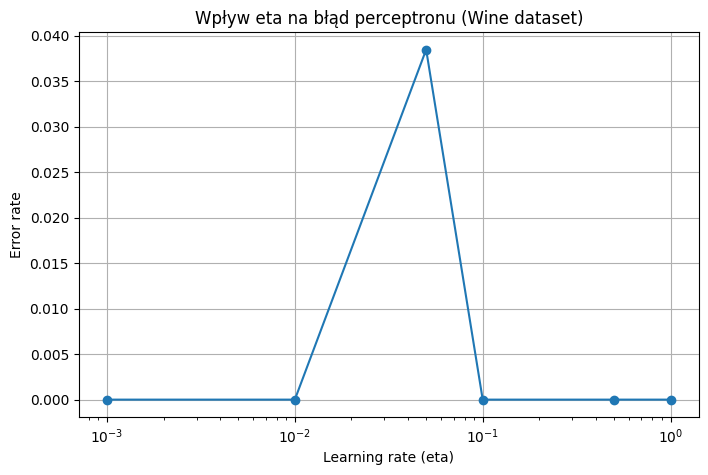

In [ ]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


wine = load_wine()
X = wine.data
y = wine.target

# binary classification (0 vs 1)
mask = y != 2
X = X[mask]
y = y[mask]

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


etas = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]

results = []

for eta in etas:
    model = Perceptron(n=X_train.shape[1])

    model.train(
        X_train,
        y_train,
        eta=eta,
        tol=0.01,
    )

    error, _ = model.evaluate_test(X_test, y_test)

    results.append({
        "eta": eta,
        "error_rate": error,
        "accuracy": 1 - error
    })


df = pd.DataFrame(results)
print("\n=== WYNIKI ===")
print(df)

plt.figure(figsize=(8, 5))

plt.plot(df["eta"], df["error_rate"], marker='o')
plt.xscale("log")
plt.xlabel("Learning rate (eta)")
plt.ylabel("Error rate")
plt.title("Wpływ eta na błąd perceptronu (Wine dataset)")
plt.grid(True)

plt.show()